# Simple EDA on Cleaned Google Play Store Dataset

This notebook performs a simple exploratory data analysis using mean, median, and variance on numeric columns.

## 1. Import Libraries

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Load the Cleaned Dataset

In [22]:
data_path = "dataset/googleplaystore_cleaned.csv"
df = pd.read_csv(data_path)

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19456.0,10000,Free,0.0,Everyone
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14336.0,500000,Free,0.0,Everyone
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8908.8,5000000,Free,0.0,Everyone
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25600.0,50000000,Free,0.0,Teen
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2867.2,100000,Free,0.0,Everyone


## 3. Preview Data and Numeric Columns

In [23]:
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn data types:")
display(df.dtypes)

numeric_df = df.select_dtypes(include="number")
print("\nNumeric columns:", list(numeric_df.columns))

Dataset shape: (9659, 9)

First 5 rows:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19456.0,10000,Free,0.0,Everyone
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14336.0,500000,Free,0.0,Everyone
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8908.8,5000000,Free,0.0,Everyone
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25600.0,50000000,Free,0.0,Teen
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2867.2,100000,Free,0.0,Everyone



Column data types:


App                   str
Category              str
Rating            float64
Reviews             int64
Size                  str
Installs            int64
Type                  str
Price             float64
Content Rating        str
dtype: object


Numeric columns: ['Rating', 'Reviews', 'Installs', 'Price']


## 4. Compute Mean for Numeric Features

In [24]:
mean_stats = numeric_df.mean()
mean_stats.to_frame(name="mean")

,mean
Rating,3.829341e+00
Reviews,2.165926e+05
Installs,7.777507e+06
Price,1.099299e+00


## 5. Compute Median for Numeric Features

In [25]:
median_stats = numeric_df.median()
median_stats.to_frame(name="median")

,median
Rating,4.2
Reviews,967.0
Installs,100000.0
Price,0.0


## 6. Compute Variance for Numeric Features

In [26]:
variance_stats = numeric_df.var()
variance_stats.to_frame(name="variance")

,variance
Rating,1.592736e+00
Reviews,3.353731e+12
Installs,2.889953e+15
Price,2.839950e+02


## 7. Build a Single EDA Summary Table

In [27]:
eda_summary = pd.DataFrame({
    "mean": mean_stats,
    "median": median_stats,
    "variance": variance_stats
})

eda_summary = eda_summary.sort_values(by="variance", ascending=False)
eda_summary

,mean,median,variance
Installs,7.777507e+06,100000.0,2.889953e+15
Reviews,2.165926e+05,967.0,3.353731e+12
Price,1.099299e+00,0.0,2.839950e+02
Rating,3.829341e+00,4.2,1.592736e+00


## 8. Visualizations
Quick visual checks for the computed summary statistics and numeric feature distributions.

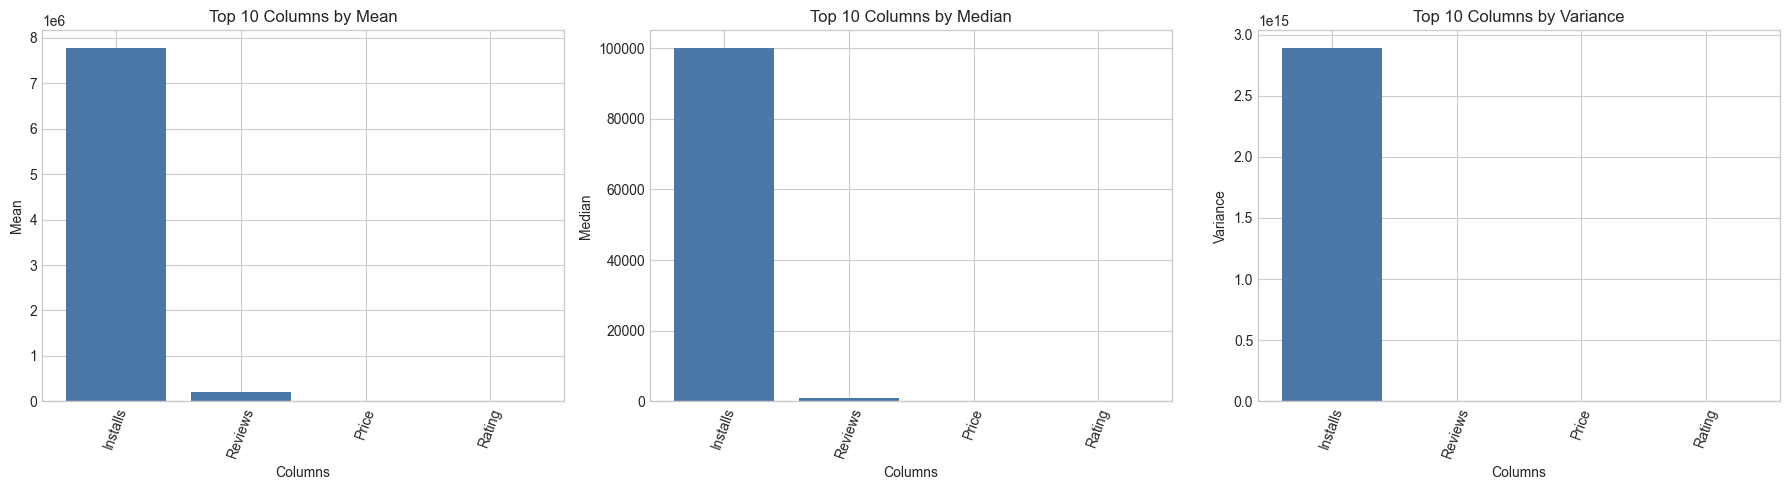

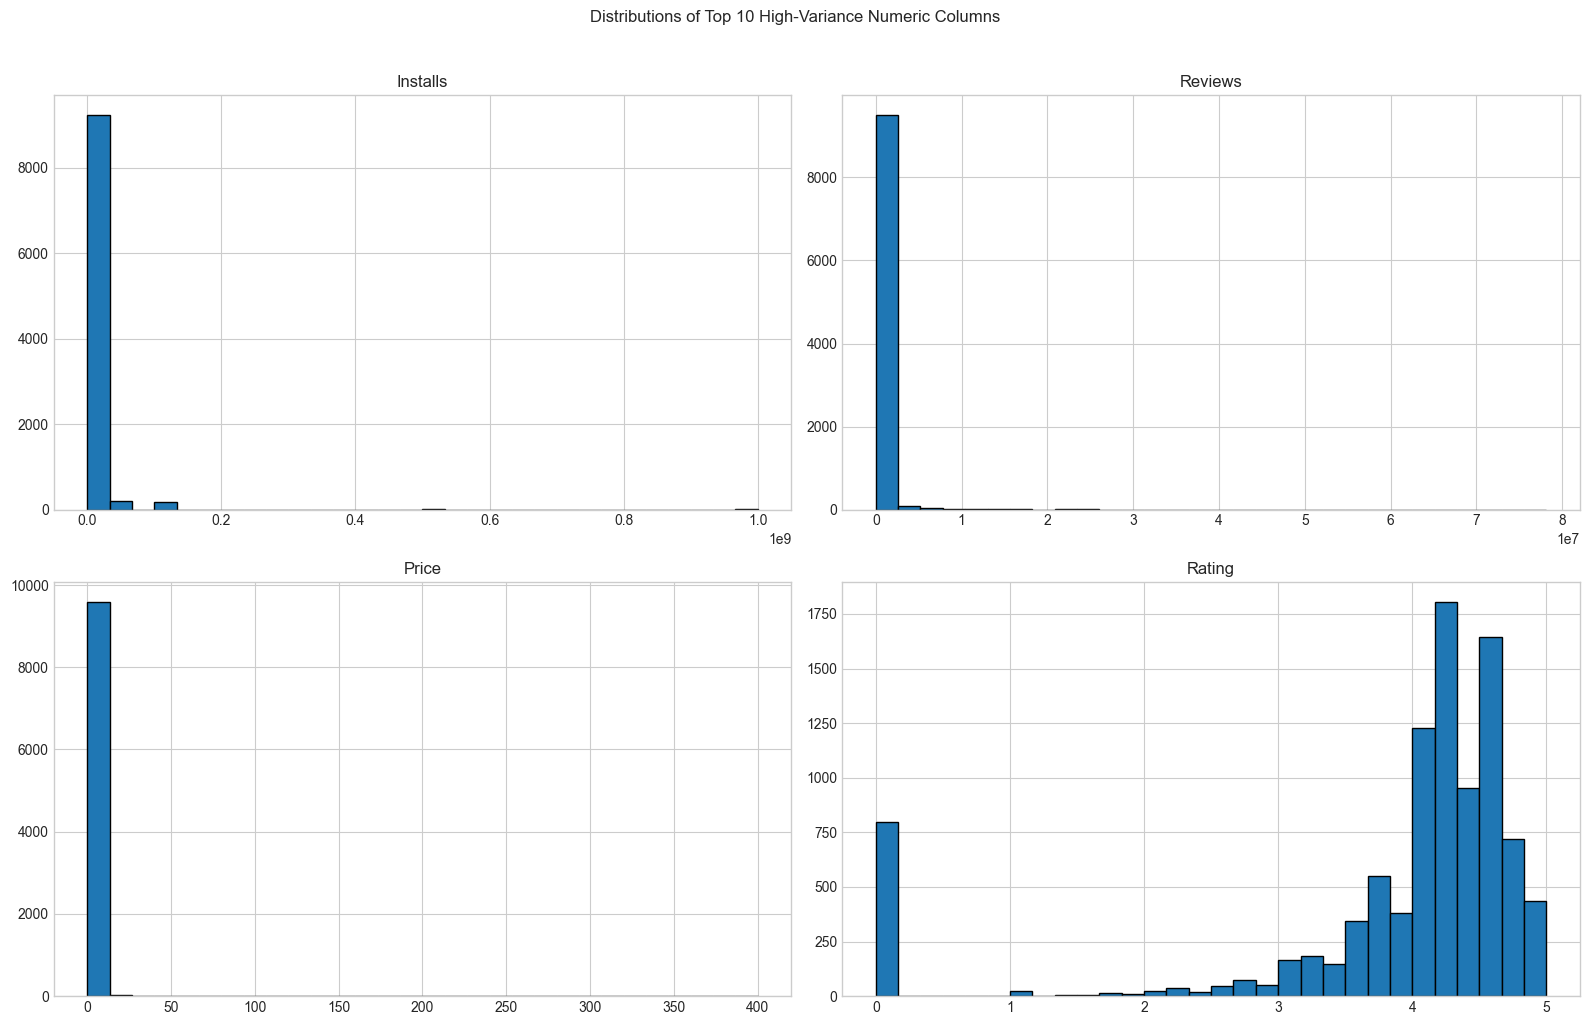

In [28]:
# Plot mean, median, and variance for the top 10 highest-variance columns
top_cols = eda_summary.head(10).index
viz_df = eda_summary.loc[top_cols, ["mean", "median", "variance"]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, stat in zip(axes, ["mean", "median", "variance"]):
    ax.bar(viz_df.index, viz_df[stat], color="#4C78A8")
    ax.set_title(f"Top 10 Columns by {stat.capitalize()}")
    ax.set_xlabel("Columns")
    ax.set_ylabel(stat.capitalize())
    ax.tick_params(axis="x", rotation=70)

plt.tight_layout()
plt.show()

# Histograms for top numeric columns by variance
numeric_df[top_cols].hist(figsize=(16, 10), bins=30, edgecolor="black")
plt.suptitle("Distributions of Top 10 High-Variance Numeric Columns", y=1.02)
plt.tight_layout()
plt.show()

## 9. Log-Scale Comparison 
These plots use a log-scaled y-axis so smaller-scale features are easier to compare with very large-scale features.

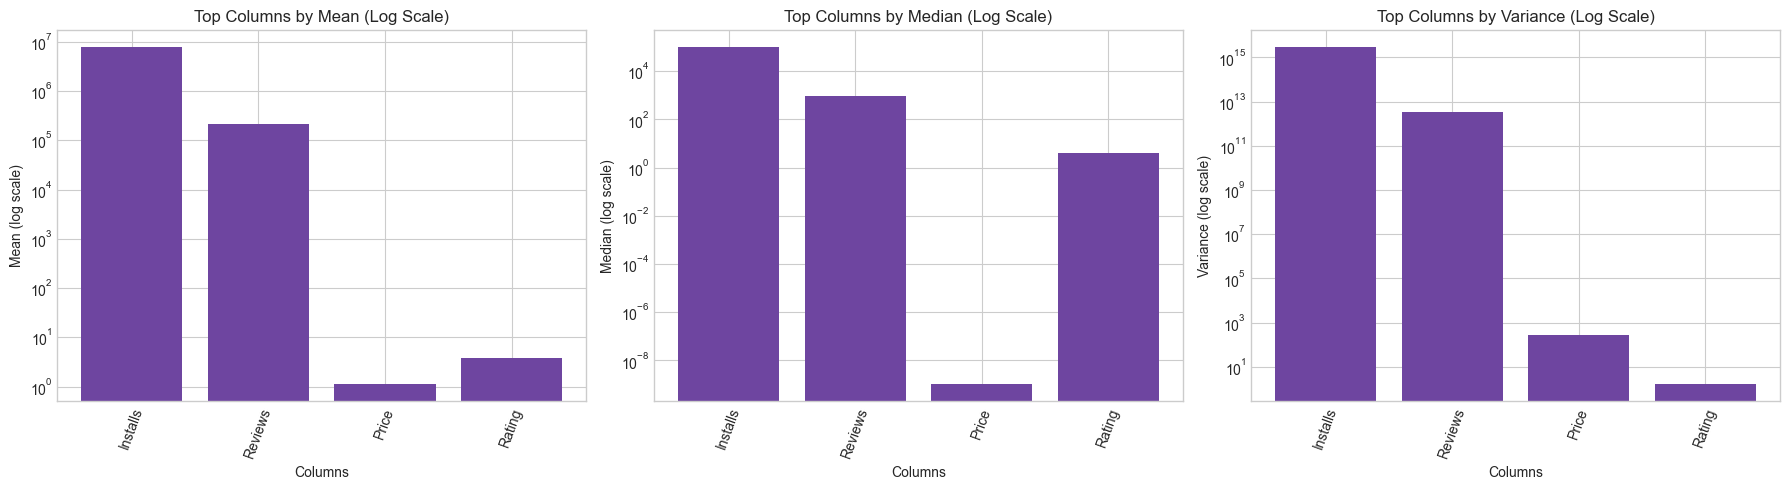

In [29]:
# Log-scale version of mean, median, and variance comparisons
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, stat in zip(axes, ["mean", "median", "variance"]):
    values = viz_df[stat].clip(lower=1e-9)
    ax.bar(viz_df.index, values, color="#6E45A0")
    ax.set_yscale("log")
    ax.set_title(f"Top Columns by {stat.capitalize()} (Log Scale)")
    ax.set_xlabel("Columns")
    ax.set_ylabel(f"{stat.capitalize()} (log scale)")
    ax.tick_params(axis="x", rotation=70)

plt.tight_layout()
plt.show()

## 10. Category-Based EDA
Compute mean, median, and variance of numeric features for each app category.

In [30]:
if "Category" not in df.columns:
    raise KeyError("Column 'Category' not found in dataset.")

numeric_cols = df.select_dtypes(include="number").columns.tolist()

category_summary = df.groupby("Category")[numeric_cols].agg(["mean", "median", "var"])
category_summary.columns = [f"{col}_{stat}" for col, stat in category_summary.columns]
category_summary = category_summary.sort_index()

category_summary.head(10)

,Rating_mean,Rating_median,Rating_var,Reviews_mean,Reviews_median,Reviews_var,Installs_mean,Installs_median,Installs_var,Price_mean,Price_median,Price_var
Category,,,,,,,,,,,,
ART_AND_DESIGN,4.304688,4.4,0.431248,22175.046875,525.0,3.717336e+09,1.786533e+06,100000.0,4.407044e+13,0.093281,0.0,0.179737
AUTO_AND_VEHICLES,3.887059,4.2,1.464711,13690.188235,348.0,1.884091e+09,6.250613e+05,100000.0,3.050994e+12,0.158471,0.0,1.236258
BEAUTY,4.026415,4.2,1.110058,7476.226415,187.0,3.646064e+08,5.131519e+05,50000.0,2.319955e+12,0.000000,0.0,0.000000
BOOKS_AND_REFERENCE,3.709009,4.4,2.377837,75321.234234,151.0,8.988616e+10,7.504367e+06,10000.0,4.659037e+15,0.539505,0.0,2.524292
BUSINESS,3.139524,4.0,3.329031,23548.202381,15.0,1.561104e+10,1.659916e+06,1000.0,7.888806e+13,0.417357,0.0,21.720746
COMICS,4.192857,4.4,0.270494,41822.696429,1576.5,2.413914e+10,8.032348e+05,100000.0,3.204332e+12,0.000000,0.0,0.000000
COMMUNICATION,3.686667,4.2,1.851414,907337.676190,1711.0,2.846290e+13,3.504215e+07,100000.0,2.243818e+16,0.263937,0.0,1.842704
DATING,3.368421,4.0,2.456526,21190.315789,277.0,4.378916e+09,8.241293e+05,10000.0,5.044785e+12,0.160468,0.0,0.889984
EDUCATION,4.367227,4.4,0.069849,112303.764706,13791.0,3.418424e+11,2.965983e+06,1000000.0,9.025954e+13,0.150924,0.0,0.685846


## 11. Quick Category Visualization
Visualize category-level mean, median, and variance for `Rating` (or fallback numeric feature).

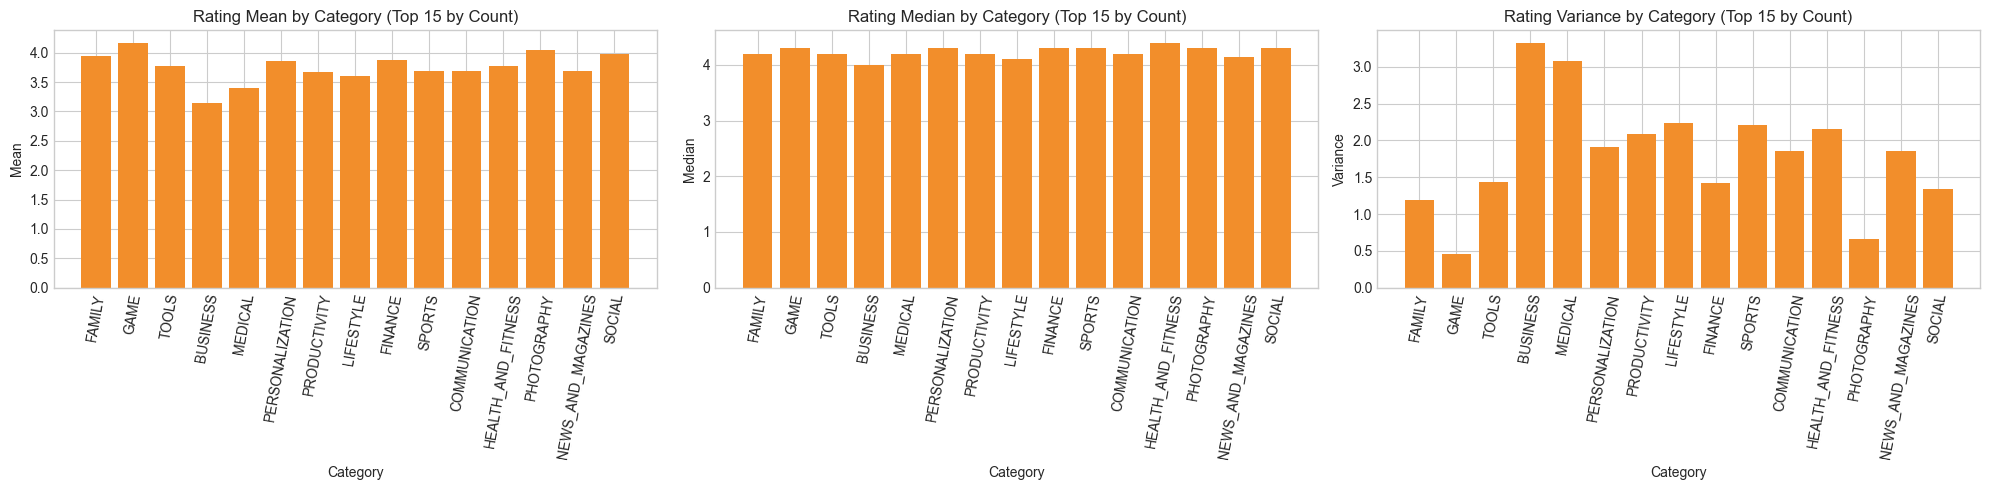

,mean,median,variance,count
Category,,,,
FAMILY,3.946834,4.20,1.192540,1832
GAME,4.171637,4.30,0.453683,959
TOOLS,3.767715,4.20,1.429550,827
BUSINESS,3.139524,4.00,3.329031,420
MEDICAL,3.392658,4.20,3.084134,395
PERSONALIZATION,3.857713,4.30,1.916740,376
PRODUCTIVITY,3.671123,4.20,2.083024,374
LIFESTYLE,3.611382,4.10,2.235957,369
FINANCE,3.868116,4.30,1.425434,345


In [31]:
metric = "Rating" if "Rating" in numeric_cols else numeric_cols[0]

cat_metric = (
    df.groupby("Category")[metric]
    .agg(mean="mean", median="median", variance="var", count="count")
    .sort_values("count", ascending=False)
)

top_cat_metric = cat_metric.head(15)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, stat in zip(axes, ["mean", "median", "variance"]):
    ax.bar(top_cat_metric.index, top_cat_metric[stat], color="#F28E2B")
    ax.set_title(f"{metric} {stat.capitalize()} by Category (Top 15 by Count)")
    ax.set_xlabel("Category")
    ax.set_ylabel(stat.capitalize())
    ax.tick_params(axis="x", rotation=80)

plt.tight_layout()
plt.show()

top_cat_metric[["mean", "median", "variance", "count"]].head(15)